# FDSI benchmark v1.1: pareto (wh_loss/sv_loss), with and without unit selection

`03a`'s Pareto search, varied in three ways. Without the CoV-ISI unit selection, it runs four
times: searching `centroid_momentum` as in `03a` or fixing it at v1.0's 0.95, each with `sv_loss`
either averaged over units (v1.1's default) or summed over units (as v1.0 did). With the unit
selection, it runs once more with `sv_loss` summed, as the counterpart of `03a`'s mean. The five
searches answer four questions:

1. **Can v1.1 reproduce v1.0?** The `no sel, cm 0.95, sum` search is the closest v1.1 gets to
   v1.0's search.
2. **Does the `sv_loss` reduction explain the gap?** Each `sum` search differs from its `mean`
   counterpart only in how `sv_loss` is reduced across units. The reduction only changes the score,
   not the adaptation, so any difference comes from which trials the sampler explores and which
   front member is selected.
3. **Can v1.1 improve on v1.0?** The searches that also tune `centroid_momentum`.
4. **Does the unit selection help?** With `centroid_momentum` searched, `03a` and the `sum` search
   pair with the `no sel` and `no sel, sum` searches, each pair differing only in the units the
   search adapts and scores. Every config is applied to all calibrated units either way.

Each `no sel` front is read twice, by `min_sv_loss` (v1.0's rule) and by `knee`; the `sum` front
only by `min_sv_loss`. That gives nine configs, which are applied to all 100 recordings and
compared unit by unit with v1.0's Pareto winner and with `03a`'s min-sv winner (`04a`'s results).

| | v1.0 (`tpe_pareto`) | v1.1 (`03a`) | v1.1, sum | v1.1, no sel | v1.1, no sel, sum | v1.1, no sel, cm 0.95 | v1.1, no sel, cm 0.95, sum |
|---|---|---|---|---|---|---|---|
| Unit selection | none | CoV-ISI ≤ 0.3 | CoV-ISI ≤ 0.3 | none | none | none | none |
| `centroid_momentum` | fixed 0.95 | searched in [0, 0.95] | searched in [0, 0.95] | searched in [0, 0.95] | searched in [0, 0.95] | fixed 0.95 | fixed 0.95 |
| Sampler | univariate TPE | multivariate TPE | multivariate TPE | multivariate TPE | multivariate TPE | multivariate TPE | multivariate TPE |
| `sv_loss` across units | sum | per-unit mean | sum | per-unit mean | sum | per-unit mean | sum |
| Search and application start | sample 0 | `CAL_END` | `CAL_END` | `CAL_END` | `CAL_END` | `CAL_END` | `CAL_END` |

In the `no sel, cm 0.95, sum` search only the sampler and the start still differ from v1.0, so a
residual gap in question 1 comes from one of those two.

## Config

In [1]:
RUN_OPTIMISATION = True  # run each search when no complete cached study exists
RUN_APPLY_BEST = True    # compute missing adaptation_v1_1/<sub>/lr_fixed/<sampler>/*.pkl
N_JOBS = 4                # recordings applied in parallel, one per worker process

import yaml
from pathlib import Path

with open('../../configs/data_configs/fdsi_benchmark_grid.yaml') as f:
    grid = yaml.safe_load(f)

DATA_DIR = Path(grid['data_root'])           # Raw archive root: <sub>/{clean,noisy}/
OUTPUTS_ROOT = Path(grid['outputs_root'])    # Precomputed-outputs archive root
CAL_DIR = OUTPUTS_ROOT / 'calibration'       # Shared with v1.0 -- written by ../fdsi_benchmark/01_calibration
ADAPT_DIR = (OUTPUTS_ROOT / 'adaptation_v1_1').resolve()  # v1.1 results
ADAPT_DIR_V10 = (OUTPUTS_ROOT / 'adaptation').resolve()  # Cached v1.0 results, read-only here
ADAPT_DIRS = {'v1.0': ADAPT_DIR_V10, 'v1.1': ADAPT_DIR}
OPT_DIR = ADAPT_DIR / 'optimisation'


FS, EXT_FACT = grid['fs'], grid['ext_fact']
TOL_SPIKE_MS, ROA_CAL_TH = grid['tol_spike_ms'], grid['roa_cal_th']
CAL_END, ISO_DUR = int(grid['cal_duration_s'] * FS), int(grid['iso_duration_s'] * FS)

SUBJECTS, CONDITIONS, SNR_LEVELS = grid['subjects'], grid['conditions'], grid['snr_levels']
TRIANGULAR = [c for c in CONDITIONS if 'triangular' in c]

POOL_CONDITIONS = grid['pool_conditions']
HOLDOUT_CONDITIONS = [c for c in CONDITIONS if c not in POOL_CONDITIONS]
OPTIM_SUB, OPTIM_SNR, N_TRIALS = grid['optim_sub'], grid['optim_snr'], grid['n_trials']

BASE_CONFIG_PATH = Path('../../configs/adapt_configs/default_muniverse.yaml')  # v1.0's base config
LR_MODE = 'fixed'   # v1.1 searches lr_fixed only -- the branch v1.0 promoted as its headline
DEVICE = 'cpu'      # deterministic, and MPS lacks the QR the sv update needs

OBJECTIVES = ('wh_loss', 'sv_loss')
CM_V10 = 0.95       # v1.0's centroid_momentum, never searched there

# Search -> {front selection rule: branch}
SEARCH_BRANCHES = {
    'pareto_sum': {'min_sv_loss': 'pareto_sum_min_sv'},
    'pareto_nosel': {'min_sv_loss': 'pareto_nosel_min_sv', 'knee': 'pareto_nosel_knee'},
    'pareto_nosel_sum': {'min_sv_loss': 'pareto_nosel_sum_min_sv', 'knee': 'pareto_nosel_sum_knee'},
    'pareto_nosel_cm095': {'min_sv_loss': 'pareto_nosel_cm095_min_sv',
                           'knee': 'pareto_nosel_cm095_knee'},
    'pareto_nosel_cm095_sum': {'min_sv_loss': 'pareto_nosel_cm095_sum_min_sv',
                               'knee': 'pareto_nosel_cm095_sum_knee'},
}
BRANCHES = [branch for rules in SEARCH_BRANCHES.values() for branch in rules.values()]

print(f'Apply-to-all grid: {len(SUBJECTS)} subjects x {len(CONDITIONS)} conditions x {len(SNR_LEVELS)} SNR levels '
      f'= {len(SUBJECTS) * len(CONDITIONS) * len(SNR_LEVELS)} recordings')
print(f'Calibration window [0, {CAL_END}) samples; adaptation starts at sample {CAL_END}')

Apply-to-all grid: 5 subjects x 5 conditions x 4 SNR levels = 100 recordings
Calibration window [0, 10240) samples; adaptation starts at sample 10240


## Calibration

The calibrations `../fdsi_benchmark/01_calibration.ipynb` wrote, shared with v1.0 and every other
v1.1 notebook. Nothing is recomputed here.

In [2]:
import sys
sys.path.insert(0, '../..')              # package root
sys.path.insert(0, '../fdsi_benchmark')  # for fdsi_common, shared with the v1.0 benchmark
sys.path.insert(0, str(Path.cwd()))      # this notebook's own directory, for fdsi_v11

from typing import Dict, Optional, Tuple
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

import numpy as np
import pandas as pd
from adapt_decomp import CBSSResult
import fdsi_common as fc
import fdsi_v11 as fv

calibrations: Dict[Tuple[str, str, int], Optional[CBSSResult]] = {}
for sub in SUBJECTS:
    for cond in CONDITIONS:
        for snr in SNR_LEVELS:
            cal_path, _ = fc.calibration_paths(CAL_DIR, sub, cond, snr)
            calibrations[(sub, cond, snr)] = CBSSResult.load(cal_path) if cal_path.exists() else None

n_cal = sum(v is not None for v in calibrations.values())
print(f'Calibration available: {n_cal}/{len(calibrations)} recordings.')

Calibration available: 100/100 recordings.


## Data pool

`03a`'s pool: the three pooled recordings, trimmed to `[CAL_END, end)`.

In [3]:
import copy
import pickle
import shutil
import time
from dataclasses import replace

import optuna
from adapt_decomp import load_data
from adapt_decomp.adaptation import AdaptConfig
from adapt_decomp.adaptation.optimize import (
    DEFAULT_PARAM_SPACE, SELECTION_RULES, optimize_adapt_decomp,
)

DATA_CONFIG_PATH = Path('../../configs/data_configs/fdsi_pool_memory_example.yaml')
with DATA_CONFIG_PATH.open() as f:
    data_config = yaml.safe_load(f)

pool = load_data(data_config)
assert set(pool) == set(POOL_CONDITIONS), pool.keys()

# Restrict every pooled recording to the samples after its calibration window
pool = {name: replace(dataset,
                      emg=dataset.emg[CAL_END:],
                      gt_paired_bin=None if dataset.gt_paired_bin is None
                                    else dataset.gt_paired_bin[CAL_END:])
        for name, dataset in pool.items()}

{name: tuple(dataset.emg.shape) for name, dataset in pool.items()}

{'triangular-ramp40s': (174080, 100),
 'triangular-ramp10s': (174080, 100),
 'triangular-ramp5s': (174080, 100)}

## Optimisation

Every search uses `03a`'s base config and search setting. The `no sel` searches set
`unit_selection=None`, so every calibrated unit is adapted and scored, as in v1.0; the `sum`
search keeps `03a`'s CoV-ISI ≤ 0.3 selection. The `cm 0.95` search leaves
`centroid_momentum` out of the space, so every trial keeps the base config's value. Each
`sum` search is its `mean` counterpart with `sv_loss_reduction='sum'`.

Each search runs only if its study isn't cached on disk, so adding a search reruns nothing else.

In [4]:
base_config = AdaptConfig.from_yaml(BASE_CONFIG_PATH)
base_config.lr_mode = LR_MODE
base_config.source_fifo_from_calib = True   # seed the source FIFO from the calibration's tail
base_config.sv_loss_reduction = 'mean'      # per-unit mean, so the loss doesn't scale with unit count
base_config.device = DEVICE

cm_fixed_config = copy.deepcopy(base_config)
cm_fixed_config.centroid_momentum = CM_V10

# v1.0's reduction, the loss scales with unit count
sum_config = copy.deepcopy(base_config)
sum_config.sv_loss_reduction = 'sum'
cm_fixed_sum_config = copy.deepcopy(cm_fixed_config)
cm_fixed_sum_config.sv_loss_reduction = 'sum'

CM_FIXED_SPACE = {name: spec for name, spec in DEFAULT_PARAM_SPACE.items() if name != 'centroid_momentum'}

# 03a's CoV-ISI unit selection, or every calibrated unit as in v1.0
UNIT_SELECTION = dict(unit_selection='unsupervised', unit_selection_kwargs={'cov_th': 0.3})
NO_UNIT_SELECTION = dict(unit_selection=None)

# Search -> (base config, param space, unit selection)
SEARCH_SETUPS = {
    'pareto_sum': (sum_config, DEFAULT_PARAM_SPACE, UNIT_SELECTION),
    'pareto_nosel': (base_config, DEFAULT_PARAM_SPACE, NO_UNIT_SELECTION),
    'pareto_nosel_sum': (sum_config, DEFAULT_PARAM_SPACE, NO_UNIT_SELECTION),
    'pareto_nosel_cm095': (cm_fixed_config, CM_FIXED_SPACE, NO_UNIT_SELECTION),
    'pareto_nosel_cm095_sum': (cm_fixed_sum_config, CM_FIXED_SPACE, NO_UNIT_SELECTION),
}

# 03a's setting (one-at-a-time trials, all available cores, v1.0's seed)
SEARCH = dict(n_jobs=1, n_cores=None, random_seed=42)

for search, (config, space, units) in SEARCH_SETUPS.items():
    print(f'{search:24} centroid_momentum={config.centroid_momentum}  '
          f'sv_loss_reduction={config.sv_loss_reduction}  '
          f'unit_selection={units["unit_selection"]}  searched={list(space)}')
print(f'search: {SEARCH}')

pareto_sum               centroid_momentum=0.95  sv_loss_reduction=sum  unit_selection=unsupervised  searched=['wh_learning_rate', 'sv_learning_rate', 'centroid_momentum']
pareto_nosel             centroid_momentum=0.95  sv_loss_reduction=mean  unit_selection=None  searched=['wh_learning_rate', 'sv_learning_rate', 'centroid_momentum']
pareto_nosel_sum         centroid_momentum=0.95  sv_loss_reduction=sum  unit_selection=None  searched=['wh_learning_rate', 'sv_learning_rate', 'centroid_momentum']
pareto_nosel_cm095       centroid_momentum=0.95  sv_loss_reduction=mean  unit_selection=None  searched=['wh_learning_rate', 'sv_learning_rate']
pareto_nosel_cm095_sum   centroid_momentum=0.95  sv_loss_reduction=sum  unit_selection=None  searched=['wh_learning_rate', 'sv_learning_rate']
search: {'n_jobs': 1, 'n_cores': None, 'random_seed': 42}


In [5]:
studies: Dict[str, optuna.Study] = {}
opt_dirs: Dict[str, Path] = {}

for search, (config, space, units) in SEARCH_SETUPS.items():
    opt_dir = OPT_DIR / fc.LR_MODE_TOKEN[LR_MODE] / fv.PARETO_VARIANT_SEARCH_DIRS[search]
    study_path = opt_dir / 'study.pkl'

    study = None
    if study_path.exists():
        with open(study_path, 'rb') as f:
            study = pickle.load(f)
    n_complete = 0 if study is None else sum(t.state.name == 'COMPLETE' for t in study.trials)

    if n_complete >= N_TRIALS:
        print(f'{search}: loading cached study ({n_complete} complete trials).')
    elif RUN_OPTIMISATION:
        shutil.rmtree(opt_dir, ignore_errors=True)
        print(f'Running {search} ({N_TRIALS} trials, objectives={OBJECTIVES}) ...')
        start = time.perf_counter()
        study = optimize_adapt_decomp(
            pool=pool,
            objectives=OBJECTIVES,
            param_space=space,
            base_config=config,
            selection='min_sv_loss',
            n_trials=N_TRIALS,
            compute_roa=True,
            roa_kwargs={'tol_spike_ms': TOL_SPIKE_MS},
            best_result_path=str(opt_dir),
            **SEARCH,
            **units,
        ).study
        study.set_user_attr('wall_time_s', time.perf_counter() - start)
        with open(study_path, 'wb') as f:
            pickle.dump(study, f)
    else:
        raise FileNotFoundError(f'No complete cached study in {opt_dir} and RUN_OPTIMISATION=False.')

    studies[search], opt_dirs[search] = study, opt_dir
    print(f'  completed trials: {sum(t.state.name == "COMPLETE" for t in study.trials)}  '
          f'front size: {len(study.best_trials)}  '
          f'wall time: {study.user_attrs.get("wall_time_s", float("nan")):.0f} s')

2026-10-04 12:59:44.199 | INFO     | adapt_decomp.adaptation.optimize.units:select_pool_units:114 - triangular-ramp40s: 13/14 units adapted and scored


2026-10-04 12:59:44.201 | INFO     | adapt_decomp.adaptation.optimize.units:select_pool_units:114 - triangular-ramp10s: 12/13 units adapted and scored


2026-10-04 12:59:44.204 | INFO     | adapt_decomp.adaptation.optimize.units:select_pool_units:114 - triangular-ramp5s: 14/14 units adapted and scored


Running pareto_sum (50 trials, objectives=('wh_loss', 'sv_loss')) ...


2026-10-04 12:59:45.533 | WARNING  | adapt_decomp.adaptation.optimize.resources:plan_search_resources:302 - Predicted peak memory 45.6 GB exceeds the 41.3 GB currently free, so the search may swap or be killed. Close other memory-heavy programs. To fit, lower n_cores (fewer runs at once), use a smaller pool or shorter recordings, use a disk pool (PooledDatasetDisk) so workers do not keep datasets resident, or request more memory (e.g. SLURM --mem).


...

2026-10-04 13:23:18.825 | INFO     | adapt_decomp.adaptation.optimize.workers:run_trials:189 - Trial 47 finished with values [3879.07958984375, 313.8864059448242] and parameters {'wh_learning_rate': 0.0004781375634172098, 'sv_learning_rate': 0.003102740950912841, 'centroid_momentum': 0.28583439432593116}


2026-10-04 13:23:49.937 | INFO     | adapt_decomp.adaptation.optimize.workers:run_trials:189 - Trial 48 finished with values [3563.942138671875, 757.9115142822266] and parameters {'wh_learning_rate': 0.000587186348818331, 'sv_learning_rate': 0.0001290211302456716, 'centroid_momentum': 0.579086117280902}


2026-10-04 13:24:21.037 | INFO     | adapt_decomp.adaptation.optimize.workers:run_trials:189 - Trial 49 finished with values [22947.36865234375, 831.8379669189453] and parameters {'wh_learning_rate': 0.002273608087915074, 'sv_learning_rate': 0.00014270403521460858, 'centroid_momentum': 0.26471414102478086}


2026-10-04 13:24:30.239 | INFO     | adapt_decomp.adaptation.optimize.search:optimize_adapt_decomp:393 - Saved search results to C:\Users\Irene\Documents\work_local\adapt_decomp\data\fdsi_benchmark\outputs\adaptation_v1_1\optimisation\lr_fixed\mtpe_pareto_sum (study.pkl, trial_12, trial_34, trial_44, trial_47, trial_48)


  completed trials: 50  front size: 5  wall time: 1486 s
pareto_nosel: loading cached study (50 complete trials).
  completed trials: 50  front size: 12  wall time: 3685 s
pareto_nosel_sum: loading cached study (50 complete trials).
  completed trials: 50  front size: 8  wall time: 3679 s
pareto_nosel_cm095: loading cached study (50 complete trials).
  completed trials: 50  front size: 13  wall time: 3772 s
pareto_nosel_cm095_sum: loading cached study (50 complete trials).
  completed trials: 50  front size: 13  wall time: 3712 s


## Search-level comparison with v1.0

v1.0's and `03a`'s cached studies, next to the five searches above, with both selection rules
applied to every front. v1.0 itself only ever used min-sv; its knee row is shown for reference.

The pooled RoA here is indicative only. v1.0 scored each trial over the whole recording, while
v1.1 scores from `CAL_END` on. The `sv_loss` values are comparable with v1.0's only for the
`no sel, sum` searches: the `mean` searches take the per-unit mean, and the unit selection scores
fewer units. The grid-level comparison further down gives the verdict.

In [6]:
PARAMS = ('wh_learning_rate', 'sv_learning_rate', 'centroid_momentum')

with open(ADAPT_DIR_V10 / 'optimisation' / fc.LR_MODE_TOKEN[LR_MODE]
          / fv.BRANCHES['pareto_min_sv'].v10_sampler / 'study.pkl', 'rb') as f:
    study_v10 = pickle.load(f)
with open(OPT_DIR / fc.LR_MODE_TOKEN[LR_MODE] / fv.SEARCH_DIRS['pareto'] / 'study.pkl', 'rb') as f:
    study_03a = pickle.load(f)

STUDY_LABELS = {'pareto_sum': 'pareto, sum (v1.1)',
                'pareto_nosel': 'pareto, no sel (v1.1)',
                'pareto_nosel_sum': 'pareto, no sel, sum (v1.1)',
                'pareto_nosel_cm095': 'pareto, no sel, cm 0.95 (v1.1)',
                'pareto_nosel_cm095_sum': 'pareto, no sel, cm 0.95, sum (v1.1)'}
all_studies = {'pareto (v1.0)': study_v10, 'pareto (v1.1)': study_03a,
               **{STUDY_LABELS[search]: study for search, study in studies.items()}}

selected = {label: {rule: SELECTION_RULES[rule](study.best_trials) for rule in ('min_sv_loss', 'knee')}
            for label, study in all_studies.items()}

rows = []
for label, study in all_studies.items():
    roa_all = [t.user_attrs.get('roa_mean_pooled', np.nan)
               for t in study.trials if t.state.name == 'COMPLETE']
    for rule, trial in selected[label].items():
        rows.append({
            'search': label, 'selection': rule, 'trial': trial.number,
            'front_size': len(study.best_trials),
            # centroid_momentum is the only parameter ever left unsearched, always at CM_V10
            **{p: trial.params.get(p, CM_V10) for p in PARAMS},
            'roa_selected': trial.user_attrs['roa_mean_pooled'],
            'roa_best_trial': np.nanmax(roa_all),
        })

pd.DataFrame(rows).set_index(['search', 'selection']).round(4)

trial  front_size  \
search                              selection                        
pareto (v1.0)                       min_sv_loss     32          14   
                                    knee            28          14   
pareto (v1.1)                       min_sv_loss     46           9   
                                    knee            48           9   
pareto, sum (v1.1)                  min_sv_loss     44           5   
                                    knee            47           5   
pareto, no sel (v1.1)               min_sv_loss     30          12   
                                    knee            35          12   
pareto, no sel, sum (v1.1)          min_sv_loss     48           8   
                                    knee            49           8   
pareto, no sel, cm 0.95 (v1.1)      min_sv_loss     26          13   
                                    knee            19          13   
pareto, no sel, cm 0.95, sum (v1.1) min_sv_loss     32          13   
                                    knee            19          13   

                                                 wh_learning_rate  \
search                              selection                       
pareto (v1.0)                       min_sv_loss            0.0404   
                                    knee                   0.0025   
pareto (v1.1)                       min_sv_loss            0.0396   
                                    knee                   0.0012   
pareto, sum (v1.1)                  min_sv_loss            0.0002   
                                    knee                   0.0005   
pareto, no sel (v1.1)               min_sv_loss            0.0371   
                                    knee                   0.0008   
pareto, no sel, sum (v1.1)          min_sv_loss            0.0052   
                                    knee                   0.0011   
pareto, no sel, cm 0.95 (v1.1)      min_sv_loss            0.0490   
                                    knee                   0.0023   
pareto, no sel, cm 0.95, sum (v1.1) min_sv_loss            0.0168   
                                    knee                   0.0023   

                                                 sv_learning_rate  \
search                              selection                       
pareto (v1.0)                       min_sv_loss            0.0024   
                                    knee                   0.0046   
pareto (v1.1)                       min_sv_loss            0.0017   
                                    knee                   0.0052   
pareto, sum (v1.1)                  min_sv_loss            0.0010   
                                    knee                   0.0031   
pareto, no sel (v1.1)               min_sv_loss            0.0015   
                                    knee                   0.0040   
pareto, no sel, sum (v1.1)          min_sv_loss            0.0042   
                                    knee                   0.0091   
pareto, no sel, cm 0.95 (v1.1)      min_sv_loss            0.0016   
                                    knee                   0.0045   
pareto, no sel, cm 0.95, sum (v1.1) min_sv_loss            0.0027   
                                    knee                   0.0045   

                                                 centroid_momentum  \
search                              selection                        
pareto (v1.0)                       min_sv_loss             0.9500   
                                    knee                    0.9500   
pareto (v1.1)                       min_sv_loss             0.7370   
                                    knee                    0.9209   
pareto, sum (v1.1)                  min_sv_loss             0.8958   
                                    knee                    0.2858   
pareto, no sel (v1.1)               min_sv_loss             0.9494   
                                    knee                    0.7577   
pareto, no sel, su

### Shared start-up trials

Both `cm 0.95` searches draw their 15 random start-up trials with v1.0's seed over the same two
parameters, so those trials should repeat v1.0's parameter sets exactly. That makes them a
same-input comparison of the two versions. The rank correlation shows whether v1.1 orders the
parameter sets the same way v1.0 did, even though the RoA windows differ. The `sum` search adapts
exactly like the `mean` one, so its start-up RoA should match the `mean` search's.

In [7]:
from scipy.stats import spearmanr

v10_trials = {t.number: t for t in study_v10.trials if t.state.name == 'COMPLETE'}
for search in ('pareto_nosel_cm095', 'pareto_nosel_cm095_sum'):
    rows = []
    for trial in studies[search].trials:
        trial_v10 = v10_trials.get(trial.number)
        if trial.state.name != 'COMPLETE' or trial_v10 is None:
            continue
        if not all(np.isclose(trial.params[p], trial_v10.params[p]) for p in PARAMS[:2]):
            continue
        rows.append({'trial': trial.number,
                     **{p: trial.params[p] for p in PARAMS[:2]},
                     'roa_v1.0': trial_v10.user_attrs['roa_mean_pooled'],
                     'roa_v1.1': trial.user_attrs['roa_mean_pooled']})

    print(STUDY_LABELS[search])
    if rows:
        df_shared = pd.DataFrame(rows).set_index('trial')
        df_shared['delta'] = df_shared['roa_v1.1'] - df_shared['roa_v1.0']
        rho = spearmanr(df_shared['roa_v1.0'], df_shared['roa_v1.1'])[0]
        print(f'{len(df_shared)} trials share v1.0\'s parameters; Spearman rho of pooled RoA = {rho:.3f}')
        display(df_shared.round(4))
    else:
        print('No trial shares v1.0\'s parameters.')

pareto, no sel, cm 0.95 (v1.1)
15 trials share v1.0's parameters; Spearman rho of pooled RoA = 0.996


,wh_learning_rate,sv_learning_rate,roa_v1.0,roa_v1.1,delta
trial,,,,,
0,0.0010,0.0711,8.2439,8.8840,0.6401
1,0.0095,0.0063,67.5082,67.2905,-0.2177
2,0.0003,0.0003,49.6425,46.6863,-2.9563
3,0.0001,0.0397,12.6796,9.4390,-3.2405
4,0.0042,0.0133,54.8944,54.8289,-0.0654
5,0.0001,0.0812,7.3942,7.1041,-0.2901
6,0.0176,0.0004,54.3156,52.2948,-2.0207
7,0.0003,0.0004,50.4650,48.3104,-2.1546
8,0.0007,0.0038,46.0792,42.3873,-3.6919


pareto, no sel, cm 0.95, sum (v1.1)
15 trials share v1.0's parameters; Spearman rho of pooled RoA = 0.996


,wh_learning_rate,sv_learning_rate,roa_v1.0,roa_v1.1,delta
trial,,,,,
0,0.0010,0.0711,8.2439,8.8840,0.6401
1,0.0095,0.0063,67.5082,67.2905,-0.2177
2,0.0003,0.0003,49.6425,46.6863,-2.9563
3,0.0001,0.0397,12.6796,9.4390,-3.2405
4,0.0042,0.0133,54.8944,54.8289,-0.0654
5,0.0001,0.0812,7.3942,7.1041,-0.2901
6,0.0176,0.0004,54.3156,52.2948,-2.0207
7,0.0003,0.0004,50.4650,48.3104,-2.1546
8,0.0007,0.0038,46.0792,42.3873,-3.6919


### Optimisation landscape -- RoA vs pooled wh_loss/sv_loss/total_loss

In [8]:
from adapt_decomp.utils.plots import plot_optimisation_landscape_grid, plot_pareto_scatter_grid

fig = plot_optimisation_landscape_grid(all_studies, {label: label for label in all_studies},
                                       {label: sel['min_sv_loss'] for label, sel in selected.items()})
fig.show()

### Pareto fronts -- wh_loss vs sv_loss, coloured by RoA

In [9]:
for rule in ('min_sv_loss', 'knee'):
    fig = plot_pareto_scatter_grid(all_studies,
                                   {label: study.best_trials for label, study in all_studies.items()},
                                   {label: sel[rule] for label, sel in selected.items()})
    fig.update_layout(title=f'Pareto fronts -- {rule} selection marked')
    fig.show()

## Promote the nine front selections

Each selected trial's config was already written by its search as `trial_<n>/config.yaml`.

In [10]:
for search, rules in SEARCH_BRANCHES.items():
    for rule, branch in rules.items():
        trial = selected[STUDY_LABELS[search]][rule]
        best_config = AdaptConfig.from_yaml(opt_dirs[search] / f'trial_{trial.number}' / 'config.yaml')
        path = fv.promoted_path(branch)
        best_config.to_yaml(path)
        print(f'{branch:26} trial {trial.number:3}  wh_lr={best_config.wh_learning_rate:.4g}  '
              f'sv_lr={best_config.sv_learning_rate:.4g}  '
              f'centroid_momentum={best_config.centroid_momentum:.3g}  -> {path.name}')

pareto_sum_min_sv          trial  44  wh_lr=0.0002106  sv_lr=0.00103  centroid_momentum=0.896  -> optim_muniverse_fdsi_v11_pareto_sum_min_sv.yaml
pareto_nosel_min_sv        trial  30  wh_lr=0.03715  sv_lr=0.001508  centroid_momentum=0.949  -> optim_muniverse_fdsi_v11_pareto_nosel_min_sv.yaml
pareto_nosel_knee          trial  35  wh_lr=0.0008028  sv_lr=0.003988  centroid_momentum=0.758  -> optim_muniverse_fdsi_v11_pareto_nosel_knee.yaml
pareto_nosel_sum_min_sv    trial  48  wh_lr=0.005225  sv_lr=0.004169  centroid_momentum=0.937  -> optim_muniverse_fdsi_v11_pareto_nosel_sum_min_sv.yaml
pareto_nosel_sum_knee      trial  49  wh_lr=0.001147  sv_lr=0.009074  centroid_momentum=0.654  -> optim_muniverse_fdsi_v11_pareto_nosel_sum_knee.yaml
pareto_nosel_cm095_min_sv  trial  26  wh_lr=0.04896  sv_lr=0.001608  centroid_momentum=0.95  -> optim_muniverse_fdsi_v11_pareto_nosel_cm095_min_sv.yaml
pareto_nosel_cm095_knee    trial  19  wh_lr=0.002278  sv_lr=0.004535  centroid_momentum=0.95  -> optim_mun

## Apply the nine configs to the full benchmark grid

Same steps as `04a`, with every branch-recording pair run in parallel. Each result is saved by
its worker as soon as it finishes, so an interrupted run resumes from the cache. Only the
branch-recording pairs without a cached result are dispatched.

In [11]:
from joblib import Parallel, delayed

from adapt_decomp import AdaptDecomp, AdaptationResult, CBSSConfig
from adapt_decomp.spikes import get_sil


def run_adapted(sub: str, cond: str, snr: int, cbss_result: Optional[CBSSResult],
                adapt_config: AdaptConfig, sampler: Optional[str]) -> Optional[AdaptationResult]:
    """Load this recording's cached v1.1 result, or compute it if RUN_APPLY_BEST is True.

    Args:
        sub (str): Subject id.
        cond (str): Condition name.
        snr (int): SNR level in dB.
        cbss_result (Optional[CBSSResult]): This recording's calibration, or None if
            calibration itself was skipped.
        adapt_config (AdaptConfig): The config to apply.
        sampler (Optional[str]): v1.1 sampler dir, or None for the fixed baseline.

    Returns:
        Optional[AdaptationResult]: The result, or None if uncached/uncomputable.
    """
    if cbss_result is None:
        return None
    lr_mode = None if sampler is None else LR_MODE
    result_path, config_path = fv.result_paths(ADAPT_DIR, sub, cond, snr, lr_mode, sampler)
    if result_path.exists():
        return AdaptationResult.load(result_path)
    if not RUN_APPLY_BEST:
        return None

    # Read back this recording's own CBSSConfig -- ext_fact etc. must match its calibration
    emg_full = fc.load_raw_emg(DATA_DIR, sub, cond, snr)
    _, cal_config_path = fc.calibration_paths(CAL_DIR, sub, cond, snr)
    cbss_config = CBSSConfig.from_yaml(cal_config_path)

    # Initialise adaptation from calibration and adapt forwards from the calibration end
    adapter = AdaptDecomp.from_calibration(calibration=cbss_result, cbss_config=cbss_config,
                                            adapt_config=adapt_config)
    outputs = adapter.process_from_calib_end(emg_full, slice(0, CAL_END))

    # Compute SIL and RoA for the full recording
    outputs.sil = get_sil(outputs.sources, outputs.spikes, adapt_config.spike_min_dist,
                           peak_power=adapt_config.spike_det_exp).numpy()
    gt_full_bin = fc.load_gt_full_bin(DATA_DIR, sub, cond, cbss_result,
                                       n_samples=outputs.spikes.shape[0])
    outputs.roa = fc.compute_roa_for_result(outputs, gt_full_bin, FS, TOL_SPIKE_MS)

    # Save the adaptation result and config
    result_path.parent.mkdir(parents=True, exist_ok=True)
    outputs.save(result_path)
    adapt_config.to_yaml(config_path)
    return outputs


def _apply_job(sub: str, cond: str, snr: int, cal: Optional[CBSSResult],
               adapt_config: AdaptConfig, sampler: Optional[str]) -> None:
    """Run one recording in a worker process, discarding the result to keep IPC small.

    Args:
        sub (str): Subject id.
        cond (str): Condition name.
        snr (int): SNR level in dB.
        cal (Optional[CBSSResult]): This recording's calibration.
        adapt_config (AdaptConfig): The config to apply.
        sampler (Optional[str]): v1.1 sampler dir.

    Returns:
        None: The result is saved to disk by run_adapted.
    """
    run_adapted(sub, cond, snr, cal, adapt_config, sampler)


best_configs = {branch: AdaptConfig.from_yaml(fv.promoted_path(branch)) for branch in BRANCHES}

# Only dispatch pairs that are calibrated and not yet cached
jobs = [(sub, cond, snr, cal, best_configs[branch], fv.BRANCHES[branch].sampler)
        for branch in BRANCHES
        for (sub, cond, snr), cal in calibrations.items()
        if cal is not None and not fv.result_paths(ADAPT_DIR, sub, cond, snr, LR_MODE,
                                                   fv.BRANCHES[branch].sampler)[0].exists()]
print(f'{len(jobs)} branch-recording pairs missing from the cache.')
pbar = tqdm(total=len(jobs), desc='Apply Pareto variants (v1.1)')
for _ in Parallel(n_jobs=N_JOBS, return_as='generator')(delayed(_apply_job)(*job) for job in jobs):
    pbar.update(1)
pbar.close()

print(f'Apply-to-all pass complete over {len(BRANCHES)} configs '
      '(or skipped where uncached and RUN_APPLY_BEST=False).')

100 branch-recording pairs missing from the cache.


Apply Pareto variants (v1.1):   0%|          | 0/100 [00:00<?, ?it/s]

C:\Users\Irene\anaconda3\envs\adapt_decomp\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Apply-to-all pass complete over 9 configs (or skipped where uncached and RUN_APPLY_BEST=False).


## Results

Everything below reads the cache off disk, so it renders whatever `RUN_APPLY_BEST` has already
produced. Every v1.1 config is paired with v1.0's Pareto winner (`pareto min-sv (v1.0)`).

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

from adapt_decomp.utils.plots import plot_metric_heatmap

sns.set_theme(style='whitegrid', font_scale=1.1)

# 04a's min-sv winner (03a: unit selection, mean) completes the unit selection x reduction pairs
RESULT_BRANCHES = ['pareto_min_sv', *BRANCHES]

CONFIG_LABELS = fv.configs(*RESULT_BRANCHES)
CONFIG_ORDER = [label for label, _, _, _ in CONFIG_LABELS]

df_roa = fv.roa_table(ADAPT_DIRS, CAL_DIR, DATA_DIR, SUBJECTS, CONDITIONS, SNR_LEVELS,
                      CONFIG_LABELS, FS, TOL_SPIKE_MS)
df_post = fv.window_roa_table(ADAPT_DIRS, CAL_DIR, DATA_DIR, SUBJECTS, CONDITIONS, SNR_LEVELS,
                              CONFIG_LABELS, slice(CAL_END, None), FS, TOL_SPIKE_MS)
configs_present = [c for c in CONFIG_ORDER if len(df_roa) and c in set(df_roa['config'])]
print(f'Configs with cached results: {configs_present}')

Configs with cached results: ['fixed (v1.0)', 'fixed (v1.1)', 'pareto min-sv (v1.0)', 'pareto min-sv (v1.1)', 'pareto min-sv, sum (v1.1)', 'pareto min-sv, no sel (v1.1)', 'pareto knee, no sel (v1.1)', 'pareto min-sv, no sel, sum (v1.1)', 'pareto knee, no sel, sum (v1.1)', 'pareto min-sv, no sel, cm 0.95 (v1.1)', 'pareto knee, no sel, cm 0.95 (v1.1)', 'pareto min-sv, no sel, cm 0.95, sum (v1.1)', 'pareto knee, no sel, cm 0.95, sum (v1.1)']


### Hyperparameters -- v1.0 winner vs the v1.1 configs

In [13]:
fv.hyperparameter_table(RESULT_BRANCHES).round(5)

,wh_learning_rate,sv_learning_rate,centroid_momentum
pareto min-sv (v1.0),0.04038,0.00242,0.95000
pareto min-sv (v1.1),0.03956,0.00167,0.73703
"pareto min-sv, sum (v1.1)",0.00021,0.00103,0.89576
"pareto min-sv, no sel (v1.1)",0.03715,0.00151,0.94939
"pareto knee, no sel (v1.1)",0.00080,0.00399,0.75767
"pareto min-sv, no sel, sum (v1.1)",0.00523,0.00417,0.93702
"pareto knee, no sel, sum (v1.1)",0.00115,0.00907,0.65380
"pareto min-sv, no sel, cm 0.95 (v1.1)",0.04896,0.00161,0.95000
"pareto knee, no sel, cm 0.95 (v1.1)",0.00228,0.00454,0.95000
"pareto min-sv, no sel, cm 0.95, sum (v1.1)",0.01684,0.00270,0.95000


### Paired per-unit RoA -- v1.0 vs v1.1

In [14]:
if len(df_roa) and len(df_post):
    display(pd.concat({'full recording': fv.paired_summary(df_roa, fv.pairs(*RESULT_BRANCHES)),
                       'after calibration': fv.paired_summary(df_post, fv.pairs(*RESULT_BRANCHES))})
            .round(3))
else:
    print('Nothing cached yet for one of the two versions.')

n_units  \
                  before               after                                                 
full recording    fixed (v1.0)         fixed (v1.1)                                    768   
                  pareto min-sv (v1.0) pareto min-sv (v1.1)                            768   
                                       pareto min-sv, sum (v1.1)                       768   
                                       pareto min-sv, no sel (v1.1)                    768   
                                       pareto knee, no sel (v1.1)                      768   
                                       pareto min-sv, no sel, sum (v1.1)               768   
                                       pareto knee, no sel, sum (v1.1)                 768   
                                       pareto min-sv, no sel, cm 0.95 (v1.1)           768   
                                       pareto knee, no sel, cm 0.95 (v1.1)             768   
                                       pareto min-sv, no sel, cm 0.95, sum (v1.1)      768   
                                       pareto knee, no sel, cm 0.95, sum (v1.1)        768   
after calibration fixed (v1.0)         fixed (v1.1)                                    768   
                  pareto min-sv (v1.0) pareto min-sv (v1.1)                            768   
                                       pareto min-sv, sum (v1.1)                       768   
                                       pareto min-sv, no sel (v1.1)                    768   
                                       pareto knee, no sel (v1.1)                      768   
                                       pareto min-sv, no sel, sum (v1.1)               768   
                                       pareto knee, no sel, sum (v1.1)                 768   
                                       pareto min-sv, no sel, cm 0.95 (v1.1)           768   
                                       pareto knee, no sel, cm 0.95 (v1.1)             768   
                                       pareto min-sv, no sel, cm 0.95, sum (v1.1)      768   
                                       pareto knee, no sel, cm 0.95, sum (v1.1)        768   

                                                                                   mean_delta  \
                  before               after                                                    
full recording    fixed (v1.0)         fixed (v1.1)                                     0.020   
                  pareto min-sv (v1.0) pareto min-sv (v1.1)                            -2.213   
                                       pareto min-sv, sum (v1.1)                      -15.064   
                                       pareto min-sv, no sel (v1.1)                    -5.027   
                                       pareto knee, no sel (v1.1)                      -6.118   
                                       pareto min-sv, no sel, sum (v1.1)                0.941   
                                       pareto knee, no sel, sum (v1.1)                 -8.136   
                                       pareto min-sv, no sel, cm 0.95 (v1.1)           -4.205   
                                       pareto knee, no sel, cm 0.95 (v1.1)             -1.922   
                                       pareto min-sv, no sel, cm 0.95, sum (v1.1)       0.367   
                                       pareto knee, no sel, cm 0.95, sum (v1.1)        -1.922   
after calibration fixed (v1.0)         fixed (v1.1)                                     0.001   
                  pareto min-sv (v1.0) pareto min-sv (v1.1)                            -2.179   
                                       pareto min-sv, sum (v1.1)                      -15.609   
                                       pareto min-sv, no sel (v1.1)                    -5.262   
                                       pareto knee, no sel (v1.1)                      -6.164   
                                       pareto min-sv, no sel, sum (v1.1)        

#### Mean / median / std RoA per config

In [15]:
WINDOW_COLS = ['version', 'config', 'condition', 'snr', 'unit', 'roa_pct']
WINDOWS = ['full recording', 'after calibration']

if len(df_roa) and len(df_post):
    df_windows = (pd.concat({'full recording': df_roa[WINDOW_COLS],
                             'after calibration': df_post[WINDOW_COLS]}, names=['window'])
                  .reset_index(level='window'))
    df_windows['window'] = pd.Categorical(df_windows['window'], WINDOWS, ordered=True)
    df_windows['config'] = pd.Categorical(df_windows['config'], configs_present, ordered=True)
    df_windows = df_windows[df_windows['config'].notna()]

    display(df_windows.groupby(['window', 'config'], observed=True)['roa_pct']
            .agg(n_units='size', mean='mean', median='median', std='std')
            .round(2))
else:
    print('Nothing cached yet for one of the two versions.')

n_units   mean  \
window            config                                                       
full recording    fixed (v1.0)                                    768  37.58   
                  fixed (v1.1)                                    768  37.60   
                  pareto min-sv (v1.0)                            768  79.25   
                  pareto min-sv (v1.1)                            768  77.03   
                  pareto min-sv, sum (v1.1)                       768  64.18   
                  pareto min-sv, no sel (v1.1)                    768  74.22   
                  pareto knee, no sel (v1.1)                      768  73.13   
                  pareto min-sv, no sel, sum (v1.1)               768  80.19   
                  pareto knee, no sel, sum (v1.1)                 768  71.11   
                  pareto min-sv, no sel, cm 0.95 (v1.1)           768  75.04   
                  pareto knee, no sel, cm 0.95 (v1.1)             768  77.32   
                  pareto min-sv, no sel, cm 0.95, sum (v1.1)      768  79.61   
                  pareto knee, no sel, cm 0.95, sum (v1.1)        768  77.32   
after calibration fixed (v1.0)                                    768  34.36   
                  fixed (v1.1)                                    768  34.36   
                  pareto min-sv (v1.0)                            768  78.40   
                  pareto min-sv (v1.1)                            768  76.22   
                  pareto min-sv, sum (v1.1)                       768  62.79   
                  pareto min-sv, no sel (v1.1)                    768  73.14   
                  pareto knee, no sel (v1.1)                      768  72.24   
                  pareto min-sv, no sel, sum (v1.1)               768  79.38   
                  pareto knee, no sel, sum (v1.1)                 768  70.16   
                  pareto min-sv, no sel, cm 0.95 (v1.1)           768  73.98   
                  pareto knee, no sel, cm 0.95 (v1.1)             768  76.42   
                  pareto min-sv, no sel, cm 0.95, sum (v1.1)      768  78.75   
                  pareto knee, no sel, cm 0.95, sum (v1.1)        768  76.42   

                                                              median    std  
window            config                                                     
full recording    fixed (v1.0)                                 34.76  12.59  
                  fixed (v1.1)                                 34.86  12.59  
                  pareto min-sv (v1.0)                         95.03  27.70  
                  pareto min-sv (v1.1)                         94.17  30.06  
                  pareto min-sv, sum (v1.1)                    69.59  29.92  
                  pareto min-sv, no sel (v1.1)                 88.69  28.96  
                  pareto knee, no sel (v1.1)                   92.58  33.27  
                  pareto min-sv, no sel, sum (v1.1)            95.65  27.85  
                  pareto knee, no sel, sum (v1.1)              92.38  35.37  
                  pareto min-sv, no sel, cm 0.95 (v1.1)        88.94  28.45  
                  pareto knee, no sel, cm 0.95 (v1.1)          93.62  29.36  
                  pareto min-sv, no sel, cm 0.95, sum (v1.1)   95.60  27.30  
                  pareto knee, no sel, cm 0.95, sum (v1.1)     93.62  29.36  
after calibration fixed (v1.0)                                 31.19  13.12  
                  fixed (v1.1)                                 31.18  13.11  
                  pareto min-sv (v1.0)                         94.94  28.74  
                  pareto min-sv (v1.1)                         94.00  31.03  
                  pareto min-sv, sum (v1.1)                    68.25  30.90  
                  pareto min-sv, no sel (v1.1)                 88.25  30.04  
                  pareto knee, no sel (v1.1)                   92.27  34.30  
                  pareto min-sv, no sel, sum (v1.1)            95.52  28.88  
                  pareto kn

#### Pool vs holdout conditions, after calibration

The search saw `POOL_CONDITIONS` and never saw `HOLDOUT_CONDITIONS`, so the gap between the two
columns shows how well each config generalises.

In [16]:
if len(df_post):
    df_split = df_post[df_post['config'].isin(configs_present)].assign(
        split=lambda d: np.where(d['condition'].isin(POOL_CONDITIONS), 'pool', 'holdout'))
    display(df_split.pivot_table(index='config', columns='split', values='roa_pct', aggfunc='mean')
            .reindex(index=configs_present, columns=['pool', 'holdout'])
            .round(2))

split,pool,holdout
config,,
fixed (v1.0),34.97,33.42
fixed (v1.1),34.98,33.41
pareto min-sv (v1.0),73.42,86.00
pareto min-sv (v1.1),72.28,82.24
"pareto min-sv, sum (v1.1)",60.55,66.22
"pareto min-sv, no sel (v1.1)",68.73,79.86
"pareto knee, no sel (v1.1)",66.74,80.63
"pareto min-sv, no sel, sum (v1.1)",72.77,89.47
"pareto knee, no sel, sum (v1.1)",64.41,78.95


#### Per-unit RoA by contraction type

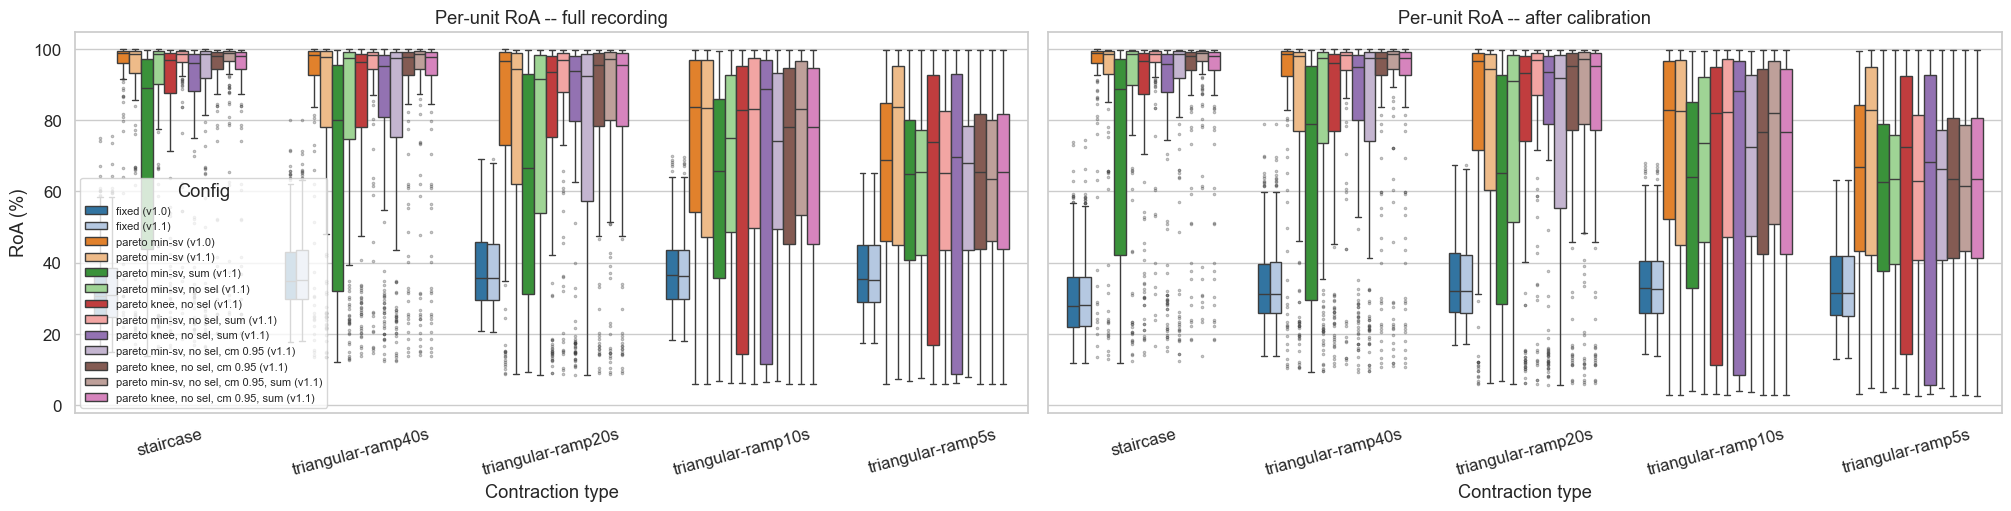

In [17]:
if len(df_roa) and len(df_post):
    fig, axs = plt.subplots(1, 2, figsize=(20, 5), layout='constrained', sharey=True)
    for ax, window in zip(axs, WINDOWS):
        sns.boxplot(
            data=df_windows[df_windows['window'] == window],
            x='condition', y='roa_pct', hue='config',
            order=CONDITIONS, hue_order=configs_present, palette='tab20',
            flierprops=dict(marker='.', markersize=3, alpha=0.4), ax=ax,
        )
        ax.set(xlabel='Contraction type', ylabel='RoA (%)', title=f'Per-unit RoA -- {window}')
        ax.tick_params(axis='x', rotation=15)
        ax.get_legend().remove()
    axs[0].legend(title='Config', fontsize=8, loc='lower left')
    plt.show()

### Paired per-unit RoA -- unit selection vs none

Each row pairs a search without unit selection (`before`) with the same search with it (`after`),
both with `centroid_momentum` searched and read by min-sv.

In [18]:
SELECTION_PAIRS = [('pareto min-sv, no sel, sum (v1.1)', 'pareto min-sv, sum (v1.1)'),
                   ('pareto min-sv, no sel (v1.1)', 'pareto min-sv (v1.1)')]

if len(df_roa) and len(df_post):
    display(pd.concat({'full recording': fv.paired_summary(df_roa, SELECTION_PAIRS),
                       'after calibration': fv.paired_summary(df_post, SELECTION_PAIRS)})
            .round(3))
else:
    print('Nothing cached yet.')

n_units  \
                  before                            after                                
full recording    pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)      768   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)           768   
after calibration pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)      768   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)           768   

                                                                               mean_delta  \
                  before                            after                                   
full recording    pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)     -16.005   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)            2.814   
after calibration pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)     -16.589   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)            3.083   

                                                                               median_delta  \
                  before                            after                                     
full recording    pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)        -6.230   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)              0.297   
after calibration pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)        -6.620   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)              0.319   

                                                                               pct_improved  \
                  before                            after                                     
full recording    pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)        16.016   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)             44.401   
after calibration pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)        16.016   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)             45.312   

                                                                               pct_unchanged  \
                  before                            after                                      
full recording    pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)         11.979   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)              42.188   
after calibration pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)         11.849   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)              41.667   

                                                                               pct_worse  \
                  before                            after                                  
full recording    pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)     72.005   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)          13.411   
after calibration pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)     72.135   
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)          13.021   

                                                                               wilcoxon_p  
                  before                            after                                  
full recording    pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)         0.0  
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)              0.0  
after calibration pareto min-sv, no sel, sum (v1.1) pareto min-sv, sum (v1.1)         0.0  
                  pareto min-sv, no sel (v1.1)      pareto min-sv (v1.1)              0.0

### Heatmaps -- mean and % units with RoA >= 90, after calibration

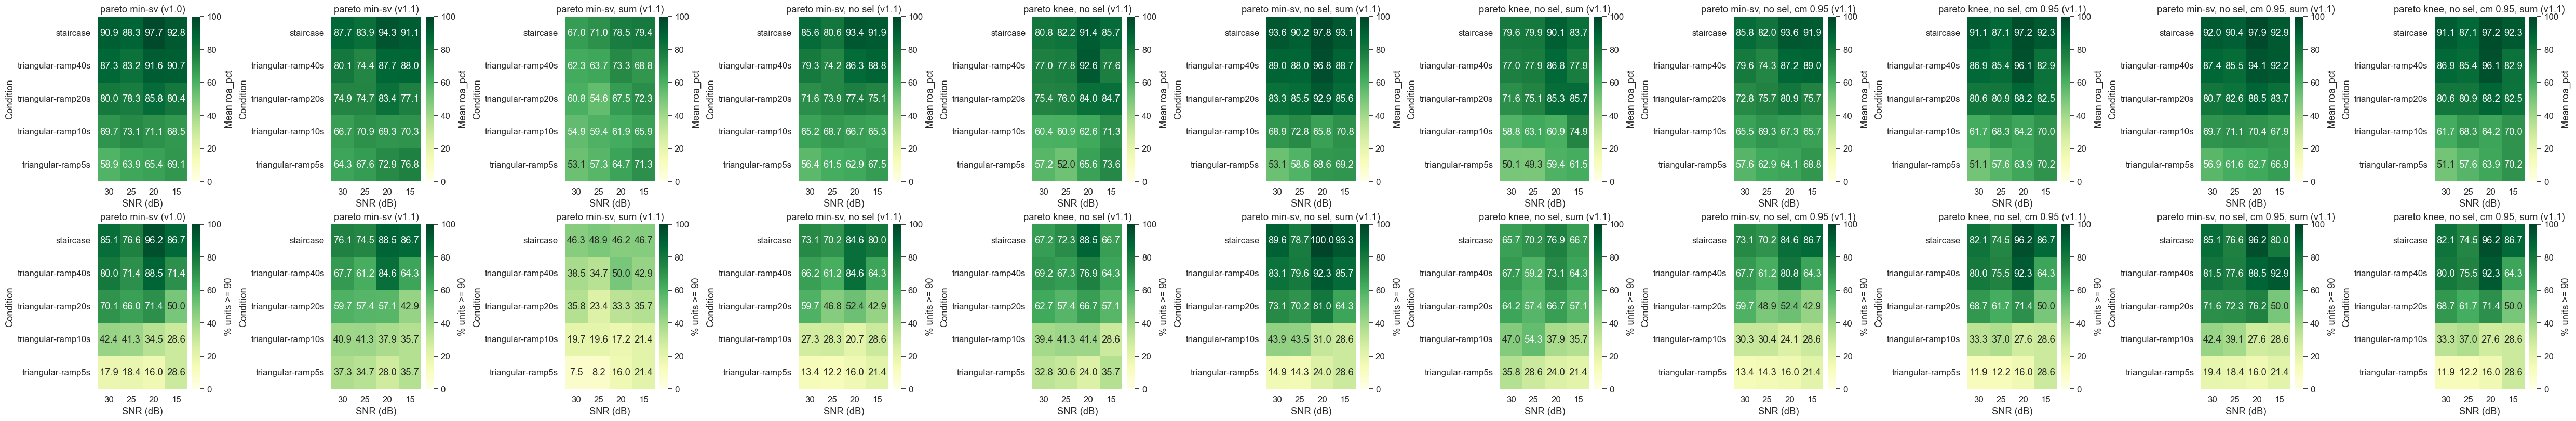

In [19]:
heatmap_configs = [c for c in configs_present if not c.startswith('fixed')]
if heatmap_configs:
    fig, axs = plt.subplots(2, len(heatmap_configs), figsize=(4.5 * len(heatmap_configs), 8),
                            layout='constrained', squeeze=False)
    plot_metric_heatmap(df_post, 'roa_pct', heatmap_configs, CONDITIONS, SNR_LEVELS,
                        agg='mean', vmin=0, vmax=100, axs=axs[0])
    plot_metric_heatmap(df_post, 'roa_pct', heatmap_configs, CONDITIONS, SNR_LEVELS,
                        agg='pct_ge_threshold', threshold=90, vmin=0, vmax=100, axs=axs[1])
    plt.show()

### Reading this

Read the `after calibration` blocks for the verdict, since `[CAL_END, end)` is the window both
versions adapted over.

1. **Reproduction:** compare `pareto min-sv, no sel, cm 0.95, sum (v1.1)` with `pareto min-sv (v1.0)`.
   A median delta near 0 and a high `pct_unchanged` mean v1.1 reproduces v1.0. A residual gap comes
   from the sampler or the start at `CAL_END`. The shared start-up trials above show the effect of
   those alone, since those trials use the same parameters.
2. **`sv_loss` reduction:** compare each `sum` row with its `mean` counterpart, e.g.
   `pareto min-sv, no sel, cm 0.95, sum (v1.1)` with `pareto min-sv, no sel, cm 0.95 (v1.1)`. If
   the `sum` rows close most of the gap to v1.0, the per-unit mean is why v1.0 does better. The
   hyperparameter table shows whether the two reductions pick different hyperparameters at all.
3. **Improvement:** a v1.1 row with a positive mean and median delta and a small Wilcoxon p
   improves on v1.0. The holdout column shows whether that gain carries over to conditions the
   search never saw.
4. **Unit selection:** read the selection-vs-none table. A positive mean and median delta in both
   rows, the `sum` pair and the `mean` pair, means the selection helps whichever reduction is used.